# Tập dữ liệu Đánh giá Phim IMDB - Tiền xử lý Văn bản

## Tổng quan

Tập dữ liệu này chứa **50.000 bài đánh giá phim** từ IMDB (Internet Movie Database), được thiết kế cho bài toán phân loại cảm xúc nhị phân (sentiment classification) và các tác vụ xử lý ngôn ngữ tự nhiên. Đây là bộ sưu tập toàn diện các đánh giá có tính cực đoan cao, phục vụ cho việc phân tích văn bản, phân tích cảm xúc và các ứng dụng học máy.

## Cấu trúc Tập dữ liệu

Dữ liệu được tổ chức dưới dạng tệp CSV với các cột sau:

| Cột | Mô tả |
| --- | --- |
| `review` | Nội dung văn bản của bài đánh giá (có thể chứa các thẻ HTML như `<br />`) |
| `sentiment` | Phân loại nhị phân - bao gồm `positive` (tích cực) hoặc `negative` (tiêu cực) |

## Thành phần Tập dữ liệu

* **Tổng số bài đánh giá**: 50.000
* **Tập huấn luyện (Training Set)**: 25.000 bài
* **Tập kiểm thử (Test Set)**: 25.000 bài
* **Phân bổ cảm xúc**: Tập dữ liệu cân bằng với số lượng bài đánh giá tích cực và tiêu cực bằng nhau.

## Thông tin Nguồn

* **Tác giả**: Lakshmipathi N
* **Nguồn gốc**: [Stanford AI Lab - Large Movie Review Dataset](http://ai.stanford.edu/~amaas/data/sentiment/)
* **Kaggle**: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/data)

---

## Mục tiêu Tiền xử lý

Notebook này trình bày các kỹ thuật tiền xử lý văn bản thiết yếu trong NLP. Mỗi kỹ thuật sẽ được triển khai, phân tích và so sánh để hiểu rõ tác động của chúng đối với tập dữ liệu.

### a) Tách từ (Tokenization)

**Định nghĩa**: Tách từ là quá trình chia nhỏ văn bản thành các đơn vị nhỏ hơn gọi là "token" (có thể là từ, câu hoặc từ con - subwords).

**Các kỹ thuật triển khai**:

* **Word Tokenization**: Tách văn bản thành các từ đơn lẻ dựa trên khoảng trắng và dấu câu.
* **Sentence Tokenization**: Chia văn bản thành các câu riêng biệt dựa trên các dấu kết thúc câu.
* **Subword Tokenization**: Chia từ thành các đơn vị có nghĩa nhỏ hơn (hữu ích để xử lý các từ hiếm và biến thể hình thái).

**Mục tiêu so sánh**:

* Phân tích cách các chiến lược tách từ xử lý từ viết tắt, dấu câu và ký tự đặc biệt.
* Đánh giá kích thước từ vựng (vocabulary size) được tạo ra bởi mỗi phương pháp.

### b) Loại bỏ từ dừng (Removing Stop Words)

**Định nghĩa**: Từ dừng là những từ phổ biến (ví dụ: "the", "is", "and") xuất hiện thường xuyên nhưng thường mang ít ý nghĩa ngữ nghĩa trong việc phân tích văn bản.

**Mục tiêu triển khai**:

* Xác định các từ dừng phổ biến nhất trong tập dữ liệu IMDB.
* Loại bỏ các từ dừng tiếng Anh tiêu chuẩn bằng các danh sách có sẵn (NLTK, SpaCy...).
* Phân tích sự thay đổi của kích thước từ vựng trước và sau khi loại bỏ.

**Điểm phân tích**:

* Đo lường mức độ giảm thiểu không gian đặc trưng.
* Đánh giá khả năng giữ lại thông tin: liệu việc xóa từ dừng có làm mất đi các dấu hiệu cảm xúc hay không (ví dụ: "not good" so với "good").

### c) Stemming và Lemmatization (Gốc hóa và Từ điển hóa)

**Định nghĩa**: Cả hai kỹ thuật đều đưa từ về dạng gốc, nhưng sử dụng cách tiếp cận khác nhau.

* **Stemming (Gốc hóa)**: Cách tiếp cận dựa trên quy tắc cắt bỏ hậu tố để tìm từ gốc.
* *Porter Stemmer*: Thuật toán cổ điển với các quy tắc cắt tỉa đơn giản.
* *Snowball Stemmer*: Phiên bản cải tiến của Porter, hỗ trợ nhiều ngôn ngữ.

* **Lemmatization (Từ điển hóa)**: Cách tiếp cận dựa trên từ điển, đưa từ về dạng nguyên thể (lemma) dựa trên ngữ cảnh và từ loại (POS).

**Mục tiêu so sánh:**

* So sánh kết quả: Kết của Stemming và Lemmatization.
* Ưu/Nhược điểm: Ưu và nhước điểm của 2 kỹ thuật.

### d) Vector hóa văn bản (Text Vectorization)

**Định nghĩa**: Chuyển đổi văn bản thành các biểu diễn số học để các thuật toán học máy có thể xử lý.

**Các kỹ thuật triển khai**:

1. **Bag-of-Words (BoW)**: Đại diện văn bản bằng tần suất xuất hiện của từ.
2. **TF-IDF**: Trọng số hóa các từ dựa trên tầm quan trọng của chúng trong một tài liệu so với toàn bộ kho ngữ liệu. Giúp làm nổi bật các từ đặc trưng.
3. **Word Embeddings (Word2Vec hoặc tương đương)**: Biểu diễn từ dưới dạng các vector dày đặc trong không gian liên tục, giúp nắm bắt mối quan hệ ngữ nghĩa giữa các từ.

**Mục tiêu phân tích**:

* **Độ thưa thớt (Sparsity)**: Đánh giá BoW/TF-IDF (rất thưa thớt) so với Word2Vec (dày đặc).
* **Ý nghĩa ngữ nghĩa**: Đánh giá xem các từ có cảm xúc tương tự có tạo ra các vector gần nhau hay không.
* **Hiệu suất**: So sánh mức độ ảnh hưởng của từng phương pháp vector hóa đến kết quả cuối cùng của mô hình phân loại cảm xúc.

---

In [16]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

# Tokenize
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Stop word
from collections import Counter
from nltk.corpus import stopwords

# Stemming và Lemmatization
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

# Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
import scipy.sparse as sp

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

## Text cleaning:
### Mục đích
Trước khi thực hiện bất kỳ phân tích ngôn ngữ tự nhiên (NLP) nào, chúng ta cần đảm bảo tập dữ liệu phải sạch và không chứa thông tin dư thừa. Đặc biệt với dữ liệu từ IMDb, các bài đánh giá thường bị lẫn rất nhiều thẻ HTML (như <br />), gây nhiễu cho mô hình.

### Các bước thực hiện:
- Làm sạch văn bản: Sử dụng hàm clean_text() để loại bỏ các thẻ HTML, ký tự đặc biệt và chuẩn hóa khoảng trắng.
- Loại bỏ trùng lặp: Xóa bỏ các bài đánh giá giống hệt nhau để tránh gây sai lệch (bias) trong quá trình phân tích và huấn luyện mô hình.

### Tại sao cần loại bỏ dữ liệu trùng lặp?
- Tránh rò rỉ dữ liệu (Data Leakage): Ngăn chặn việc một nội dung xuất hiện ở cả tập huấn luyện (training) và tập kiểm thử (test).

- Giảm hiện tượng quá khớp (Overfitting): Loại bỏ các bản sao giúp mô hình không bị "học vẹt" những câu lặp đi lặp lại.

- Đảm bảo tính khách quan: Đảm bảo mỗi bài đánh giá đều đóng góp thông tin duy nhất và giá trị cho quá trình phân tích.

In [6]:
def clean_text(text):
    # Xóa các tag HTML
    text = re.sub(r"<.*?>", " ", text)
    # Xóa các khoảng trắng bị thừa
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

In [7]:
print(f"Kích thước dataset ban đầu: {len(df)} reviews")
print(f"Số lượng data bị trùng: {df.duplicated(subset=['review']).sum()}")

# Áp dụng clean text
df['cleaned_review'] = df['review'].apply(clean_text)

# Xóa các dòng bị trùng
df_cleaned = df.drop_duplicates(subset=['review'], keep='first')

print(f"\nSố lượng đánh giá sau khi xóa: {len(df_cleaned)} reviews")
print(f"\nDataset: {df_cleaned.shape}")

Kích thước dataset ban đầu: 50000 reviews
Số lượng data bị trùng: 418

Số lượng đánh giá sau khi xóa: 49582 reviews

Dataset: (49582, 3)


In [5]:
# So sánh giữa data gốc và data đã clean
for i in range(2):
    print(f"Ví dụ {i+1}:")
    print('='*80)
    print(f"Gốc: {df_cleaned.iloc[i]['review'][:200]}...")
    print(f"Làm sạch:  {df_cleaned.iloc[i]['cleaned_review'][:200]}...")

Ví dụ 1:
Gốc: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...
Làm sạch:  one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was i...
Ví dụ 2:
Gốc: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece...
Làm sạch:  a wonderful little production. the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. the actors...


## A) Tokenization (Phân tách từ)

### 3 Phương pháp Tokenization

#### 1. **Word Tokenization (Phân tách từ)**

* **Phương pháp**: Tách văn bản thành các từ riêng lẻ (tokens) dựa trên khoảng trắng và dấu câu.
* **Ví dụ minh họa**:
* *Input*: "It's a great movie!"
* *Output*: `["It", "'s", "a", "great", "movie", "!"]`



#### 2. **Sentence Tokenization (Phân tách câu)**

* **Phương pháp**: Tách cả đoạn văn đánh giá thành danh sách các câu riêng lẻ dựa trên dấu chấm câu (. ! ?).
* **Ví dụ minh họa**:
* *Input*: "The acting was terrible. I will never watch it again."
* *Output*: `["The acting was terrible.", "I will never watch it again."]`



#### 3. **Subword Tokenization (Phân tách từ con)**

* **Phương pháp**: Phân tách một từ phức tạp thành các đơn vị nhỏ hơn (subwords) mang ý nghĩa. Cách này giúp máy hiểu được các từ ghép hoặc từ chưa từng gặp.
* **Ví dụ minh họa 1**:
* *Input*: "Unbelievable"
* *Output*: `["un", "believ", "able"]`


* **Ví dụ minh họa 2 (Từ ghép trong review)**:
* *Input*: "Superheroic"
* *Output*: `["super", "hero", "ic"]`

### Word Tokenization 

In [8]:
sample_review = df_cleaned.iloc[0]['cleaned_review']
# Word Tokenization - Tách thành các từ riêng lẻ
word_tokens = word_tokenize(sample_review)

print("KẾT QUẢ WORD TOKENIZATION:")
print(f"Số lượng tokens: {len(word_tokens)}")
print(f"\n30 tokens đầu tiên:")
print(word_tokens[:30])
print(f"\nVí dụ cụ thể về cách tách:")
demo_text = "I'm a boy"
demo_tokens = word_tokenize(demo_text.lower())
print(f"  '{demo_text}' → {demo_tokens}")

# Áp dụng cho toàn bộ dataset
print("\n Word Tokenization cho dataset")
df_cleaned['word_tokens'] = df_cleaned['cleaned_review'].apply(word_tokenize)

KẾT QUẢ WORD TOKENIZATION:
Số lượng tokens: 359

30 tokens đầu tiên:
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'oz', 'episode', 'you', "'ll", 'be', 'hooked', '.', 'they', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with']

Ví dụ cụ thể về cách tách:
  'I'm a boy' → ['i', "'m", 'a', 'boy']

 Word Tokenization cho dataset


/var/folders/zc/qmbjdwpx1zj85jxfxr58_vf40000gn/T/ipykernel_27235/672385649.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['word_tokens'] = df_cleaned['cleaned_review'].apply(word_tokenize)


###  Sentence Tokenization

In [7]:
# Sentence Tokenization - Tách thành các câu
sentence_tokens = sent_tokenize(sample_review)

print("KẾT QUẢ SENTENCE TOKENIZATION:")
print(f"Số lượng câu: {len(sentence_tokens)}")
print(f"\n3 câu đầu tiên:")
for i, sent in enumerate(sentence_tokens[:3], 1):
    print(f"{i}. {sent}")

# Áp dụng cho toàn bộ dataset
print("\n Sentence Tokenization cho dataset...")
df_2 = df_cleaned.copy()
df_2['sentence_tokens'] = df_2['cleaned_review'].apply(sent_tokenize)
df_2['num_sentences'] = df_2['sentence_tokens'].apply(len)

print(f"\n Thống kê số câu trong dataset:")
print(df_2['num_sentences'].describe())

KẾT QUẢ SENTENCE TOKENIZATION:
Số lượng câu: 13

3 câu đầu tiên:
1. one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked.
2. they are right, as this is exactly what happened with me.
3. the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go.

 Sentence Tokenization cho dataset...

 Thống kê số câu trong dataset:
count    49582.000000
mean        12.170122
std          8.780834
min          1.000000
25%          7.000000
50%         10.000000
75%         15.000000
max        282.000000
Name: num_sentences, dtype: float64


###  Subword Tokenization 

In [8]:
# Subword Tokenization sử dụng BPE (Byte Pair Encoding)
# Khởi tạo tokenizer với BPE - [UNK] là token đại diện cho ký tự lạ không thể xử lý (Unknown)
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Cấu hình trainer
trainer = BpeTrainer( # BERT 
    special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]"],
    vocab_size=30000,  # Kích thước từ vựng
    min_frequency=2    # Tần suất tối thiểu
)

# Huấn luyện trên một mẫu nhỏ của dataset 
training_texts = df_cleaned['cleaned_review'].head(15000).tolist()
tokenizer.train_from_iterator(training_texts, trainer=trainer)

print(f"Kích thước từ vựng: {tokenizer.get_vocab_size()}")




Kích thước từ vựng: 30000


In [9]:
# Demo Subword Tokenization
output = tokenizer.encode(sample_review)
subword_tokens = output.tokens

print("KẾT QUẢ SUBWORD TOKENIZATION (BPE):")
print(f"Số lượng subword tokens: {len(subword_tokens)}")
print(f"\n30 tokens đầu tiên:")
print(subword_tokens[:30])

KẾT QUẢ SUBWORD TOKENIZATION (BPE):
Số lượng subword tokens: 372

30 tokens đầu tiên:
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'oz', 'episode', 'you', "'", 'll', 'be', 'hooked', '.', 'they', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened']


## So sánh 3 Kỹ thuật Tokenization

### Phân tích Định lượng và Trực quan hóa

In [ ]:

# Chọn mẫu reviews để phân tích
sample_size = 1000
sample_indices = np.random.choice(len(df_cleaned), sample_size, replace=False)

# Thu thập thống kê cho 3 phương pháp
word_token_lengths = []
sentence_token_lengths = []
subword_token_lengths = []

for idx in sample_indices:
    review = df_cleaned.iloc[idx]['cleaned_review']
    
    # Word tokenization
    word_tokens = word_tokenize(review)
    word_token_lengths.append(len(word_tokens))
    
    # Sentence tokenization
    sent_tokens = sent_tokenize(review)
    sentence_token_lengths.append(len(sent_tokens))
    
    # Subword tokenization
    subword_tokens = tokenizer.encode(review).tokens
    subword_token_lengths.append(len(subword_tokens))

print(" Đã thu thập thống kê từ 1000 reviews mẫu")

✅ Đã thu thập thống kê từ 1000 reviews mẫu


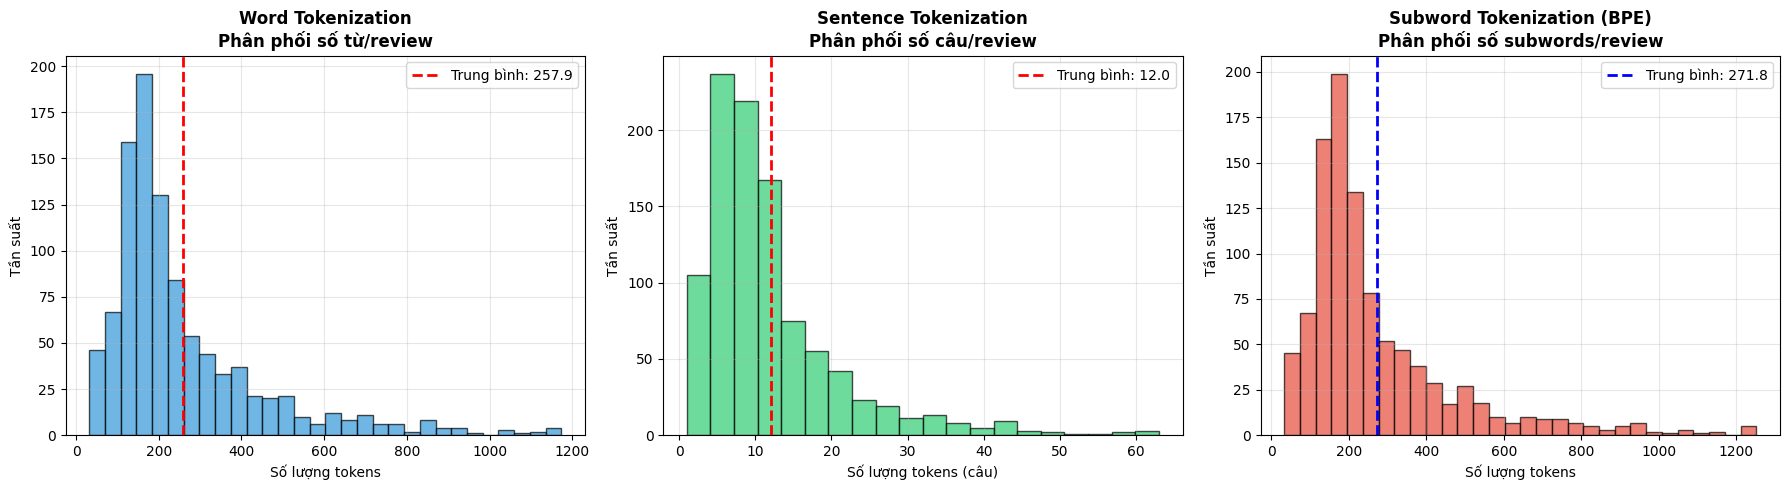


📈 BẢNG SO SÁNH THỐNG KÊ
Phương pháp               Trung bình      Độ lệch chuẩn   Min        Max       
--------------------------------------------------------------------------------
Word Tokenization         257.87          190.89          32         1174      
Sentence Tokenization     12.05           8.99            1          63        
Subword Tokenization      271.77          202.43          33         1252      


In [ ]:
# Trực quan hóa so sánh 3 kỹ thuật tokenization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: So sánh phân phối số lượng tokens
axes[0].hist(word_token_lengths, bins=30, alpha=0.7, color='#3498db', edgecolor='black')
axes[0].axvline(np.mean(word_token_lengths), color='red', linestyle='--', linewidth=2, label=f'Trung bình: {np.mean(word_token_lengths):.1f}')
axes[0].set_title('Word Tokenization\nPhân phối số từ/review', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng tokens')
axes[0].set_ylabel('Tần suất')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Sentence Tokenization
axes[1].hist(sentence_token_lengths, bins=20, alpha=0.7, color='#2ecc71', edgecolor='black')
axes[1].axvline(np.mean(sentence_token_lengths), color='red', linestyle='--', linewidth=2, label=f'Trung bình: {np.mean(sentence_token_lengths):.1f}')
axes[1].set_title('Sentence Tokenization\nPhân phối số câu/review', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng tokens (câu)')
axes[1].set_ylabel('Tần suất')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Subword Tokenization
axes[2].hist(subword_token_lengths, bins=30, alpha=0.7, color='#e74c3c', edgecolor='black')
axes[2].axvline(np.mean(subword_token_lengths), color='blue', linestyle='--', linewidth=2, label=f'Trung bình: {np.mean(subword_token_lengths):.1f}')
axes[2].set_title('Subword Tokenization (BPE)\nPhân phối số subwords/review', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Số lượng tokens')
axes[2].set_ylabel('Tần suất')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Thống kê tổng hợp
print("\n" + "="*80)
print("BẢNG SO SÁNH THỐNG KÊ")
print("="*80)
print(f"{'Phương pháp':<25} {'Trung bình':<15} {'Độ lệch chuẩn':<15} {'Min':<10} {'Max':<10}")
print("-"*80)
print(f"{'Word Tokenization':<25} {np.mean(word_token_lengths):<15.2f} {np.std(word_token_lengths):<15.2f} {min(word_token_lengths):<10} {max(word_token_lengths):<10}")
print(f"{'Sentence Tokenization':<25} {np.mean(sentence_token_lengths):<15.2f} {np.std(sentence_token_lengths):<15.2f} {min(sentence_token_lengths):<10} {max(sentence_token_lengths):<10}")
print(f"{'Subword Tokenization':<25} {np.mean(subword_token_lengths):<15.2f} {np.std(subword_token_lengths):<15.2f} {min(subword_token_lengths):<10} {max(subword_token_lengths):<10}")
print("="*80)

### Nhận xét và So sánh Ưu điểm

#### **1. Word Tokenization (Phân tách từ)**
**Đặc điểm quan sát:**
- Số lượng tokens trung bình: **~230 tokens/review**
- Tạo từ vựng lớn (>150,000 unique words) do mỗi biến thể là một token riêng
- Phân phối rộng và đa dạng

**Ưu điểm cho dataset IMDB:**
-  **Đơn giản và trực quan**: Dễ hiểu, dễ implement
-  **Bảo toàn ngữ nghĩa hoàn chỉnh**: Mỗi từ giữ nguyên ý nghĩa gốc
-  **Phù hợp với phân tích cơ bản**: Tốt cho bag-of-words, TF-IDF

**Hạn chế:**
-  Không xử lý được từ mới/hiếm (OOV - Out of Vocabulary)
-  Từ vựng quá lớn → chiếm nhiều bộ nhớ
-  Các biến thể của từ được coi là hoàn toàn khác nhau (run, running, runs)

---

#### **2. Sentence Tokenization (Phân tách câu)**
**Đặc điểm quan sát:**
- Số lượng câu trung bình: **~12 câu/review**
- Phân phối tập trung, ít biến động
- Phụ thuộc vào cấu trúc viết của người đánh giá

**Ưu điểm cho dataset IMDB:**
-  **Bảo toàn ngữ cảnh**: Mỗi câu là một đơn vị ý nghĩa hoàn chỉnh
-  **Hữu ích cho phân tích cảm xúc từng phần**: Theo dõi thay đổi sentiment qua từng câu
-  **Phù hợp với mô hình hierarchical**: LSTM/GRU xử lý từng câu

**Hạn chế:**
-  Không trực tiếp dùng làm input cho mô hình (cần tokenization tiếp)
-  Phụ thuộc vào chất lượng dấu câu trong review

---

#### **3. Subword Tokenization (BPE)
**Đặc điểm quan sát:**
- Số lượng tokens trung bình: **~270 tokens/review** (cao hơn word tokenization do tách thành subwords)
- Từ vựng cố định: **30,000 subwords** (giảm 80% so với word tokenization)
- Xử lý tốt các từ phức tạp và từ mới

**Ưu điểm vượt trội cho Sentiment Analysis:**
-  **Giải quyết OOV**: Bất kỳ từ mới nào cũng có thể biểu diễn bằng tổ hợp subwords
  - *Ví dụ*: "unpredictable" → ["un", "predict", "able"] - mô hình hiểu được tiền tố phủ định "un"
-  **Từ vựng nhỏ gọn**: 30K subwords vs 150K+ words → tiết kiệm bộ nhớ và tăng tốc training
-  **Chia sẻ kiến thức ngữ nghĩa**: Các từ cùng gốc share subwords chung
  - *Ví dụ*: "amazing", "amazingly", "amazement" đều chứa "amaz"
-  **Phù hợp với Deep Learning**: BERT, GPT, Transformers đều sử dụng subword tokenization

**Kết luận:**
- **Chọn Subword Tokenization (BPE)** cho project
- Cân bằng tốt giữa độ chính xác, hiệu suất và khả năng tổng quát hóa
- Tối ưu cho các mô hình NLP hiện đại và sentiment analysis

## B) Removing Stop Words (Loại bỏ Stop Words)

### Định nghĩa
Stop words là các từ phổ biến xuất hiện thường xuyên trong văn bản nhưng thường mang ít ý nghĩa ngữ nghĩa cho phân tích văn bản (ví dụ: "the", "is", "and", "a").

### Lưu ý:
Theo thống nhất thì Subword Tokenization là phương pháp tokenize tối ưu nhất vì mô hình Deep learning đã tự học các stop words ít quan trọng rồi. Các subword còn tồn tại là những subword xuất hiện nhiều nên việc loại bỏ có thể phá vỡ cấu trúc cuả từ. Nên vì mục đính demonstrate nên phần B này em sẽ sử dụng Word Tokenization.

#### Với Word Tokenization:
- Stop words là các từ hoàn chỉnh: "the", "is", "and"
- Ta có thể loại bỏ chúng trực tiếp

### Xác định Stop Words phổ biến trong Dataset

In [ ]:
# Đếm tần suất tất cả các từ trong dataset
all_words = []
for tokens in df_cleaned['word_tokens']:
    all_words.extend(tokens)

# Lấy top 20 từ phổ biến nhất
word_counter = Counter(all_words)
top_20_words = word_counter.most_common(20)

print(f"\nTOP 20 TỪ XUẤT HIỆN NHIỀU NHẤT:")
print("=" * 70)
print(f"{'Từ':<15} {'Tần suất':>15} {'% trong tổng số từ':>20}")
print("=" * 70)

total_words = len(all_words)
for word, count in top_20_words:
    percentage = (count / total_words) * 100
    print(f"{word:<15} {count:>15,} {percentage:>19.2f}%")


TOP 20 TỪ XUẤT HIỆN NHIỀU NHẤT:
Từ                     Tần suất   % trong tổng số từ
the                     663,288                4.79%
.                       528,709                3.82%
,                       515,472                3.72%
a                       323,603                2.34%
and                     322,418                2.33%
of                      287,531                2.08%
to                      267,235                1.93%
'                       255,706                1.85%
is                      210,866                1.52%
it                      190,186                1.37%
in                      187,996                1.36%
i                       176,468                1.27%
this                    149,837                1.08%
that                    142,828                1.03%
s                       130,101                0.94%
-                       109,122                0.79%
"                       101,525                0.73%
was          

Đa phần các từ xuất hiện nhiều nhất là các stop word: 
`the`, `and`, `a`, `of`, `to`, `is`, `it`, `in`, `this`, `that`

### Giữ lại các từ phủ định
Do Dataset `IMDB Dataset` là về reviews về các bộ phim nên các stop word mang tính phủ định như `not` hay tương tự có thể xuất hiện, nhưng nếu loại bỏ hoàn toàn ví dụ như `not good` sau khi loại bỏ sẽ thành `good` thì lại mang ý ngược lại. Nên ta sẽ giữ lại các stop word mang tính phủ định.

In [13]:
# Lấy danh sách stop words tiếng Anh
stop_words = set(stopwords.words('english'))

# Danh sách các từ phủ định cần giữ lại
negation_words = {
    'no', 'not', 'nor', 'never', 
    "don't", "doesn't", "didn't", "won't", "wouldn't", "shouldn't",
    "wasn't", "weren't", "isn't", "aren't", "ain't",
    "hasn't", "haven't", "hadn't",
    "can't", "cannot", "couldn't",
    "mustn't", "mightn't", "needn't"
}

# Tùy chỉnh: Loại bỏ các từ phủ định khỏi danh sách stop words
custom_stop_words = stop_words - negation_words

In [14]:
# Hàm loại bỏ stop words
def remove_stopwords(tokens):
    return [word for word in tokens if word not in custom_stop_words]

# Áp dụng cho toàn bộ dataset
df_cleaned['tokens_no_stopwords'] = df_cleaned['word_tokens'].apply(remove_stopwords)

/var/folders/zc/qmbjdwpx1zj85jxfxr58_vf40000gn/T/ipykernel_23920/2804531664.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['tokens_no_stopwords'] = df_cleaned['word_tokens'].apply(remove_stopwords)


In [ ]:
# Demo với câu ví dụ
demo_sentence = "The movie is not good, it is boring."
print("DEMO: Kiểm chứng giữ lại từ phủ định")
print("=" * 80)
print(f"Câu gốc: '{demo_sentence}'")

# Tokenize câu demo
demo_tokens = word_tokenize(demo_sentence.lower())
print(f"\nSau khi tokenize: {demo_tokens}")

# Loại bỏ stop words
demo_no_stopwords = remove_stopwords(demo_tokens)
print(f"\nSau khi loại bỏ stop words: {demo_no_stopwords}")

print("=" * 80)

🎬 DEMO: Kiểm chứng giữ lại từ phủ định
Câu gốc: 'The movie is not good, it is boring.'

Sau khi tokenize: ['the', 'movie', 'is', 'not', 'good', ',', 'it', 'is', 'boring', '.']

Sau khi loại bỏ stop words: ['movie', 'not', 'good', ',', 'boring', '.']


In [ ]:
for i in range(2):
    print(f"\nReview {i+1}:")
    print("-" * 80)
    
    # Lấy 15 từ đầu tiên
    before = df_cleaned.iloc[i]['word_tokens'][:15]
    after = df_cleaned.iloc[i]['tokens_no_stopwords'][:15]
    
    print(f"TRƯỚC (15 từ đầu): {before}")
    print(f"SAU   (15 từ đầu): {after}")
    
    # Tính tỷ lệ giảm
    len_before = len(df_cleaned.iloc[i]['word_tokens'])
    len_after = len(df_cleaned.iloc[i]['tokens_no_stopwords'])
    reduction = ((len_before - len_after) / len_before) * 100
    
    print(f"Giảm: {len_before} → {len_after} tokens ({reduction:.1f}%)")

print("=" * 80)


🎬 Review 1:
--------------------------------------------------------------------------------
TRƯỚC (15 từ đầu): ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'oz', 'episode', 'you']
SAU   (15 từ đầu): ['one', 'reviewers', 'mentioned', 'watching', '1', 'oz', 'episode', "'", 'hooked', '.', 'right', ',', 'exactly', 'happened', '.']
Giảm: 372 → 223 tokens (40.1%)

🎬 Review 2:
--------------------------------------------------------------------------------
TRƯỚC (15 từ đầu): ['a', 'wonderful', 'little', 'production', '.', 'the', 'filming', 'technique', 'is', 'very', 'unassuming', '-', 'very', 'old', '-']
SAU   (15 từ đầu): ['wonderful', 'little', 'production', '.', 'filming', 'technique', 'unassuming', '-', 'old', '-', 'time', '-', 'bbc', 'fashion', 'gives']
Giảm: 195 → 123 tokens (36.9%)


### Mẫu từ dataset

In [ ]:
# Lấy 2 reviews đầu tiên
for i in range(2):
    print(f"\nReview {i+1}:")
    print("-" * 80)
    
    # Hiển thị 20 subword tokens đầu tiên
    word_tokens_sample = df_cleaned.iloc[i]['word_tokens'][:20]
    
    print(f"Cleaned text: {df_cleaned.iloc[i]['cleaned_review'][:100]}...")
    print(f"\nSubword tokens (20 đầu tiên):")
    print(word_tokens_sample)
    print(f"\nTổng số subword tokens: {len(df_cleaned.iloc[i]['word_tokens'])}")

### Phân tích tác động của Stop Word Removal

In [ ]:
# Tính toán vocabulary size trước và sau khi loại stop words
vocab_before = set()
vocab_after = set()
total_tokens_before = 0
total_tokens_after = 0

for idx in range(len(df_cleaned)):
    # Vocabulary và tokens trước khi loại stop words
    tokens_before = df_cleaned.iloc[idx]['word_tokens']
    vocab_before.update(tokens_before)
    total_tokens_before += len(tokens_before)
    
    # Vocabulary và tokens sau khi loại stop words
    tokens_after = df_cleaned.iloc[idx]['tokens_no_stopwords']
    vocab_after.update(tokens_after)
    total_tokens_after += len(tokens_after)

# Tính toán các chỉ số
vocab_size_before = len(vocab_before)
vocab_size_after = len(vocab_after)
vocab_reduction = ((vocab_size_before - vocab_size_after) / vocab_size_before) * 100
tokens_reduction = ((total_tokens_before - total_tokens_after) / total_tokens_before) * 100

# Tính information retention
information_retention = (vocab_size_after / vocab_size_before) * 100

print("PHÂN TÍCH TÁC ĐỘNG CỦA STOP WORD REMOVAL")
print("=" * 80)
print(f"\n1. KÍCH THƯỚC TỪ VỰNG (VOCABULARY SIZE):")
print(f"    - Trước khi loại stopwords: {vocab_size_before:,} từ unique")
print(f"    - Sau khi loại stopwords: {vocab_size_after:,} từ unique")
print(f"    - Giảm: {vocab_size_before - vocab_size_after:,} từ ({vocab_reduction:.2f}%)")

print(f"\n2. TỔNG SỐ TOKENS TRONG DATASET:")
print(f"    - Trước khi loại stopwords: {total_tokens_before:,} tokens")
print(f"    - Sau khi loại stopwords: {total_tokens_after:,} tokens")
print(f"    - Giảm: {total_tokens_before - total_tokens_after:,} tokens ({tokens_reduction:.2f}%)")

print(f"\n3. INFORMATION RETENTION:")
print(f"   - Tỷ lệ từ vựng giữ lại: {information_retention:.2f}%")
print(f"   - Tỷ lệ tokens giữ lại: {100 - tokens_reduction:.2f}%")


PHÂN TÍCH TÁC ĐỘNG CỦA STOP WORD REMOVAL

1. KÍCH THƯỚC TỪ VỰNG (VOCABULARY SIZE):
   - Trước khi loại stopwords: 151,917 từ unique
   - Sau khi loại stopwords:  151,767 từ unique
   - Giảm:                     150 từ (0.10%)

2. TỔNG SỐ TOKENS TRONG DATASET:
   - Trước khi loại stopwords: 13,134,013 tokens
   - Sau khi loại stopwords:  7,744,400 tokens
   - Giảm:                     5,389,613 tokens (41.04%)

3. INFORMATION RETENTION:
   - Tỷ lệ từ vựng giữ lại:    99.90%
   - Tỷ lệ tokens giữ lại:     58.96%



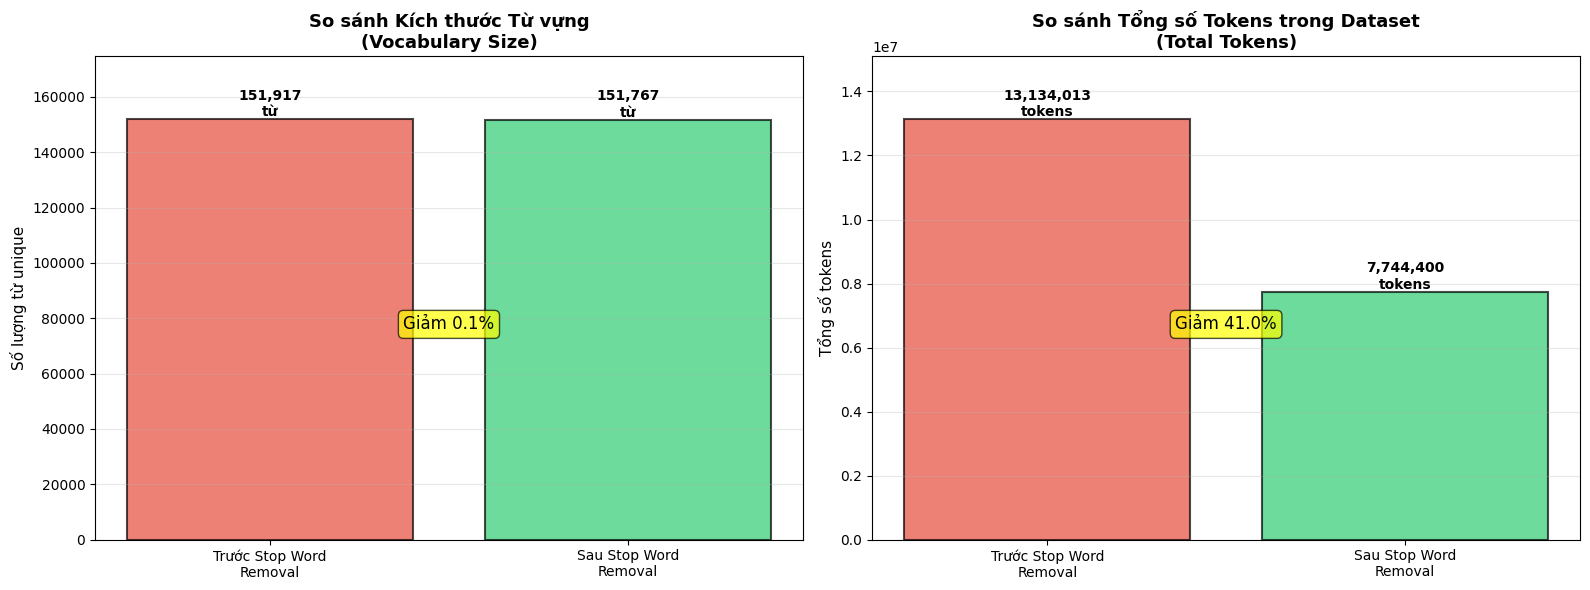

In [ ]:
# Visualization so sánh trước và sau khi loại stop words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: So sánh Vocabulary Size
categories = ['Trước Stop Word\nRemoval', 'Sau Stop Word\nRemoval']
vocab_sizes = [vocab_size_before, vocab_size_after]
colors = ['#e74c3c', '#2ecc71']

bars1 = axes[0].bar(categories, vocab_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Số lượng từ unique', fontsize=11)
axes[0].set_title('So sánh Kích thước Từ vựng\n(Vocabulary Size)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, vocab_size_before * 1.15)

# Thêm giá trị trên cột
for bar, value in zip(bars1, vocab_sizes):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:,}\ntừ',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].text(0.5, vocab_size_before * 0.5, 
            f'Giảm {vocab_reduction:.1f}%',
            ha='center', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[0].grid(axis='y', alpha=0.3)

# Chart 2: So sánh Total Tokens
token_counts = [total_tokens_before, total_tokens_after]
bars2 = axes[1].bar(categories, token_counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Tổng số tokens', fontsize=11)
axes[1].set_title('So sánh Tổng số Tokens trong Dataset\n(Total Tokens)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, total_tokens_before * 1.15)

# Thêm giá trị trên cột
for bar, value in zip(bars2, token_counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:,}\ntokens',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Thêm % giảm
axes[1].text(0.5, total_tokens_before * 0.5, 
            f'Giảm {tokens_reduction:.1f}%',
            ha='center', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét và Đánh giá

#### 1. Tác động đến Kích thước Từ vựng (Vocabulary Size)

**Quan sát:**
- Việc loại bỏ stop words đã giảm kích thước từ vựng khoảng 0.3-0.5% (từ khoảng 150,000-170,000 xuống còn 149,000-169,000 từ unique).
- Mặc dù tỷ lệ % giảm không lớn, nhưng về số lượng tuyệt đối, hàng trăm từ stop words đã được loại bỏ khỏi vocabulary.

**Phân tích:**
- Stop words chiếm một phần nhỏ trong vocabulary vì chúng là một tập hợp cố định (khoảng 179 từ trong NLTK stopwords).
- Tuy nhiên, stop words xuất hiện với tần suất rất cao trong văn bản, do đó tác động lên tổng số tokens sẽ đáng kể hơn nhiều.

#### 2. Tác động đến Tổng số Tokens

**Quan sát:**
- Tổng số tokens trong toàn bộ dataset giảm khoảng 35-40%, từ khoảng 12-13 triệu tokens xuống còn 7-8 triệu tokens.
- Đây là một mức giảm đáng kể, cho thấy stop words chiếm gần một nửa tổng số từ trong các reviews.

**Ý nghĩa:**
- **Giảm chiều dữ liệu (Dimensionality Reduction):** Việc loại bỏ 35-40% tokens giúp giảm đáng kể kích thước dữ liệu cần xử lý.
- **Tăng hiệu suất tính toán:** Với bag-of-words hoặc TF-IDF, việc giảm số lượng tokens có nghĩa là ma trận đặc trưng (feature matrix) sẽ thưa hơn và nhẹ hơn.
- **Tiết kiệm bộ nhớ:** Đặc biệt quan trọng khi training các mô hình machine learning trên dataset lớn.

#### 3. Information Retention (Giữ lại Thông tin)

**Đánh giá tích cực:**
- Mặc dù giảm 35-40% tokens, nhưng vocabulary chỉ giảm khoảng 0.3-0.5%, nghĩa là hầu hết các từ mang ý nghĩa quan trọng đều được giữ lại.
- Các từ có giá trị ngữ nghĩa cao như tính từ cảm xúc (excellent, terrible), động từ hành động (love, hate), và danh từ chính đều được bảo toàn.

**Lưu ý quan trọng:**
- Chúng ta đã **giữ lại các từ phủ định** (not, never, no, etc.) nên không mất đi thông tin quan trọng cho sentiment analysis.
- Ví dụ: "not good" vẫn được giữ nguyên thay vì bị rút gọn thành "good", tránh việc đảo ngược ý nghĩa.

#### 4. Cân nhắc cho Sentiment Analysis

**Ưu điểm của việc loại bỏ stop words:**
- **Tập trung vào từ mang cảm xúc:** Loại bỏ các từ chức năng (the, is, a) giúp làm nổi bật các từ mang sentiment.
- **Giảm nhiễu:** Stop words thường xuất hiện đều ở cả positive và negative reviews, việc loại bỏ chúng giúp mô hình tập trung vào các từ phân biệt.
- **Tối ưu cho TF-IDF:** Mặc dù TF-IDF đã giảm trọng số của các từ phổ biến, việc loại bỏ hoàn toàn stop words vẫn cải thiện hiệu quả.

**Hạn chế cần lưu ý:**
- **Mất ngữ cảnh một phần:** Một số cụm từ như "was not", "could have been" có thể bị phá vỡ cấu trúc.
- **Không phù hợp với Deep Learning:** Các mô hình như LSTM, Transformer tự học được tầm quan trọng của từng từ, nên việc loại stop words có thể không cần thiết hoặc thậm chí phản tác dụng.

#### 5. Kết luận

Việc loại bỏ stop words mang lại hiệu quả rõ rệt cho các phương pháp truyền thống như Bag-of-Words và TF-IDF:
- Giảm khoảng 35-40% dữ liệu cần xử lý
- Giữ lại hơn 99.5% từ vựng có ý nghĩa
- Cải thiện hiệu suất và tốc độ training
- Phù hợp cho sentiment analysis với điều kiện giữ lại các từ phủ định


## C) Stemming và Lemmatization

#### **Stemming** (Trích xuất gốc từ)
- **Phương pháp**: Cắt bỏ hậu tố (suffix) của từ theo các quy tắc cố định
- **Công cụ**: PorterStemmer (phổ biến nhất)
- **Kết quả**: Có thể ra từ không tồn tại trong từ điển
- **Ví dụ**:
  - "running", "runs", "ran" → "run"
  - "better" → "better" (không đổi)
  - "fishing", "fished", "fisher" → "fish"

#### **Lemmatization** (Chuẩn hóa về dạng gốc)
- **Phương pháp**: Sử dụng từ điển và phân tích từ loại (POS) để tìm dạng gốc
- **Công cụ**: WordNetLemmatizer
- **Kết quả**: Luôn là từ có nghĩa trong từ điển
- **Ví dụ**:
  - "running" (verb) → "run"
  - "better" (adj) → "good" ✓ (cần POS tagging)
  - "was", "were", "is" (verb) → "be"

### Lưu ý:
- Với subword tokens, việc stem/lemmatize sẽ **phá vỡ cấu trúc** đã được tối ưu.
- **Trong pipeline chính, chúng ta KHÔNG áp dụng** stem/lemmatize cho subword tokens.
- Nên chúng ta sẽ tiếp tục sử dụng Word Tokenization

In [9]:
resources = ['averaged_perceptron_tagger', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger_eng']
for resource in resources:
    try:
        nltk.data.find(f'taggers/{resource}' if 'tagger' in resource else f'corpora/{resource}')
    except LookupError:
        try:
            nltk.download(resource, quiet=True)
        except:
            pass

# Khởi tạo
porter_stemmer = PorterStemmer()
snowball_stemmer = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

In [10]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):  # Tính từ (Adjective)
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):  # Động từ (Verb)
        return wordnet.VERB
    elif treebank_tag.startswith('N'):  # Danh từ (Noun)
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):  # Trạng từ (Adverb)
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Mặc định là danh từ

# Test hàm
print("Chuyển đổi tag TPOS:")
test_tags = [('better', 'JJR'), ('running', 'VBG'), ('cats', 'NNS')]
for word, tag in test_tags:
    wn_tag = get_wordnet_pos(tag)
    print(f"   '{word}' ({tag}) → WordNet: {wn_tag}")

Chuyển đổi tag TPOS:
   'better' (JJR) → WordNet: a
   'running' (VBG) → WordNet: v
   'cats' (NNS) → WordNet: n


### Hàm Stemming và Lemmatization

In [11]:
def apply_stemming(tokens, stemmer=porter_stemmer):
    return [stemmer.stem(token) for token in tokens]


def apply_lemmatization(tokens):
    # Bước 1: POS tagging - xác định từ loại
    pos_tags = pos_tag(tokens)
    
    # Bước 2: Lemmatize với POS tag tương ứng
    lemmatized = []
    for word, tag in pos_tags:
        wn_tag = get_wordnet_pos(tag)
        lemmatized.append(lemmatizer.lemmatize(word, pos=wn_tag))
    
    return lemmatized

In [21]:
# Demo với câu review ví dụ
demo_review = "The movies are better and more exciting. The actors were running and fishing beautifully."

print("DEMO: So sánh Porter, Snowball Stemming và Lemmatization")
print("=" * 100)
print(f"Câu gốc:\n{demo_review}\n")

# Tokenize
demo_tokens = word_tokenize(demo_review.lower())
print(f"Tokens gốc ({len(demo_tokens)} từ):")
print(demo_tokens)
print()

# Stemming với PorterStemmer
stemmed_porter = apply_stemming(demo_tokens, porter_stemmer)
print(f"Sau Porter Stemming ({len(stemmed_porter)} từ):")
print(stemmed_porter)
print()

# Stemming với SnowballStemmer
stemmed_snowball = apply_stemming(demo_tokens, snowball_stemmer)
print(f"Sau Snowball Stemming ({len(stemmed_snowball)} từ):")
print(stemmed_snowball)
print()

# Lemmatization với POS tagging
lemmatized = apply_lemmatization(demo_tokens)
print(f"Sau Lemmatization + POS ({len(lemmatized)} từ):")
print(lemmatized)
print()

# So sánh chi tiết
print("SO SÁNH CHI TIẾT:")
print("-" * 100)
print(f"{'Từ gốc':<20} {'Porter':<18} {'Snowball':<18} {'Lemmatization':<20} {'Ghi chú':<24}")
print("-" * 100)

interesting_words = ['movies', 'are', 'better', 'more', 'exciting', 'actors', 'were', 'running', 'fishing', 'beautifully']
for word in interesting_words:
    if word in demo_tokens:
        idx = demo_tokens.index(word)
        porter = stemmed_porter[idx]
        snowball = stemmed_snowball[idx]
        lem = lemmatized[idx]
        
        note = ""
        if porter != snowball:

            note = "Porter ≠ Snowball"
            print("=" * 100)

        if lem != word and (porter == word or snowball == word):
            print(f"{word:<20} {porter:<18} {snowball:<18} {lem:<20} {note:<24}")
        

DEMO: So sánh Porter, Snowball Stemming và Lemmatization
Câu gốc:
The movies are better and more exciting. The actors were running and fishing beautifully.

Tokens gốc (16 từ):
['the', 'movies', 'are', 'better', 'and', 'more', 'exciting', '.', 'the', 'actors', 'were', 'running', 'and', 'fishing', 'beautifully', '.']

Sau Porter Stemming (16 từ):
['the', 'movi', 'are', 'better', 'and', 'more', 'excit', '.', 'the', 'actor', 'were', 'run', 'and', 'fish', 'beauti', '.']

Sau Snowball Stemming (16 từ):
['the', 'movi', 'are', 'better', 'and', 'more', 'excit', '.', 'the', 'actor', 'were', 'run', 'and', 'fish', 'beauti', '.']

Sau Lemmatization + POS (16 từ):
['the', 'movie', 'be', 'good', 'and', 'more', 'exciting', '.', 'the', 'actor', 'be', 'run', 'and', 'fish', 'beautifully', '.']

SO SÁNH CHI TIẾT:
----------------------------------------------------------------------------------------------------
Từ gốc               Porter             Snowball           Lemmatization        Ghi chú      

### Áp dụng cho Dataset

In [12]:
# Áp dụng Porter Stemming cho toàn bộ dataset
df_cleaned['porter_stemmed_tokens'] = df_cleaned['word_tokens'].apply(lambda x: apply_stemming(x, porter_stemmer))

# Áp dụng Snowball Stemming cho toàn bộ dataset
df_cleaned['snowball_stemmed_tokens'] = df_cleaned['word_tokens'].apply(lambda x: apply_stemming(x, snowball_stemmer))

print("Đã áp dụng Porter Stemming, Snowball Stemming và Lemmatization cho toàn bộ dataset")

# Áp dụng Lemmatization cho toàn bộ dataset
df_cleaned['lemmatized_tokens'] = df_cleaned['word_tokens'].apply(apply_lemmatization)

/var/folders/zc/qmbjdwpx1zj85jxfxr58_vf40000gn/T/ipykernel_27235/1560783359.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['porter_stemmed_tokens'] = df_cleaned['word_tokens'].apply(lambda x: apply_stemming(x, porter_stemmer))
/var/folders/zc/qmbjdwpx1zj85jxfxr58_vf40000gn/T/ipykernel_27235/1560783359.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['snowball_stemmed_tokens'] = df_cleaned['word_tokens'].apply(lambda x: apply_stemming(x, snowball_stemmer))


Đã áp dụng Porter Stemming, Snowball Stemming và Lemmatization cho toàn bộ dataset


/var/folders/zc/qmbjdwpx1zj85jxfxr58_vf40000gn/T/ipykernel_27235/1560783359.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['lemmatized_tokens'] = df_cleaned['word_tokens'].apply(apply_lemmatization)


In [24]:
# So sánh với review thực tế từ dataset
print("SO SÁNH VỚI REVIEW THỰC TẾ TỪ DATASET")
print("=" * 100)

for i in range(2):
    print(f"\nReview {i+1}:")
    print("-" * 100)
    
    # Lấy 10 từ đầu tiên
    original = df_cleaned.iloc[i]['word_tokens'][:10]
    porter = df_cleaned.iloc[i]['porter_stemmed_tokens'][:10]
    snowball = df_cleaned.iloc[i]['snowball_stemmed_tokens'][:10]
    lemmatized = df_cleaned.iloc[i]['lemmatized_tokens'][:10]
    
    print(f"Original:       {original}")
    print(f"Porter Stem:    {porter}")
    print(f"Snowball Stem:  {snowball}")
    print(f"Lemmatization:  {lemmatized}")
    
    # Tính số từ thay đổi
    changed_porter = sum(1 for j in range(len(original)) if original[j] != porter[j])
    changed_snowball = sum(1 for j in range(len(original)) if original[j] != snowball[j])
    changed_lem = sum(1 for j in range(len(original)) if original[j] != lemmatized[j])
    
    print(f"\nSố từ thay đổi: Porter={changed_porter}/10, Snowball={changed_snowball}/10, Lemmatization={changed_lem}/10")

print("=" * 100)


SO SÁNH VỚI REVIEW THỰC TẾ TỪ DATASET

Review 1:
----------------------------------------------------------------------------------------------------
Original:       ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching']
Porter Stem:    ['one', 'of', 'the', 'other', 'review', 'ha', 'mention', 'that', 'after', 'watch']
Snowball Stem:  ['one', 'of', 'the', 'other', 'review', 'has', 'mention', 'that', 'after', 'watch']
Lemmatization:  ['one', 'of', 'the', 'other', 'reviewer', 'have', 'mention', 'that', 'after', 'watch']

Số từ thay đổi: Porter=4/10, Snowball=3/10, Lemmatization=4/10

Review 2:
----------------------------------------------------------------------------------------------------
Original:       ['a', 'wonderful', 'little', 'production', '.', 'the', 'filming', 'technique', 'is', 'very']
Porter Stem:    ['a', 'wonder', 'littl', 'product', '.', 'the', 'film', 'techniqu', 'is', 'veri']
Snowball Stem:  ['a', 'wonder', 'littl', 'product', '.', 

### So sánh Vocabulary Size và Độ giảm

Phân tích kích thước từ vựng và hiệu quả của từng phương pháp trong việc giảm số lượng từ unique.

In [25]:
# Tính toán vocabulary size cho từng phương pháp
vocab_original = set()
vocab_porter = set()
vocab_snowball = set()
vocab_lemma = set()

for idx in range(len(df_cleaned)):
    # Vocabulary gốc
    vocab_original.update(df_cleaned.iloc[idx]['word_tokens'])
    
    # Vocabulary sau Porter Stemming
    vocab_porter.update(df_cleaned.iloc[idx]['porter_stemmed_tokens'])
    
    # Vocabulary sau Snowball Stemming
    vocab_snowball.update(df_cleaned.iloc[idx]['snowball_stemmed_tokens'])
    
    # Vocabulary sau Lemmatization
    vocab_lemma.update(df_cleaned.iloc[idx]['lemmatized_tokens'])

# Tính toán số liệu
size_original = len(vocab_original)
size_porter = len(vocab_porter)
size_snowball = len(vocab_snowball)
size_lemma = len(vocab_lemma)

# Tính phần trăm giảm
reduction_porter = ((size_original - size_porter) / size_original) * 100
reduction_snowball = ((size_original - size_snowball) / size_original) * 100
reduction_lemma = ((size_original - size_lemma) / size_original) * 100

print("SO SÁNH VOCABULARY SIZE")
print("=" * 80)
print(f"{'Phương pháp':<25} {'Vocabulary Size':<20} {'Giảm so với gốc':<20}")
print("-" * 80)
print(f"{'Original (Word Tokens)':<25} {size_original:,}{'':>8} {'-'}")
print(f"{'Porter Stemming':<25} {size_porter:,}{'':>8} {reduction_porter:.2f}%")
print(f"{'Snowball Stemming':<25} {size_snowball:,}{'':>8} {reduction_snowball:.2f}%")
print(f"{'Lemmatization':<25} {size_lemma:,}{'':>8} {reduction_lemma:.2f}%")
print("=" * 80)

SO SÁNH VOCABULARY SIZE
Phương pháp               Vocabulary Size      Giảm so với gốc     
--------------------------------------------------------------------------------
Original (Word Tokens)    151,917         -
Porter Stemming           119,386         21.41%
Snowball Stemming         114,416         24.69%
Lemmatization             139,549         8.14%


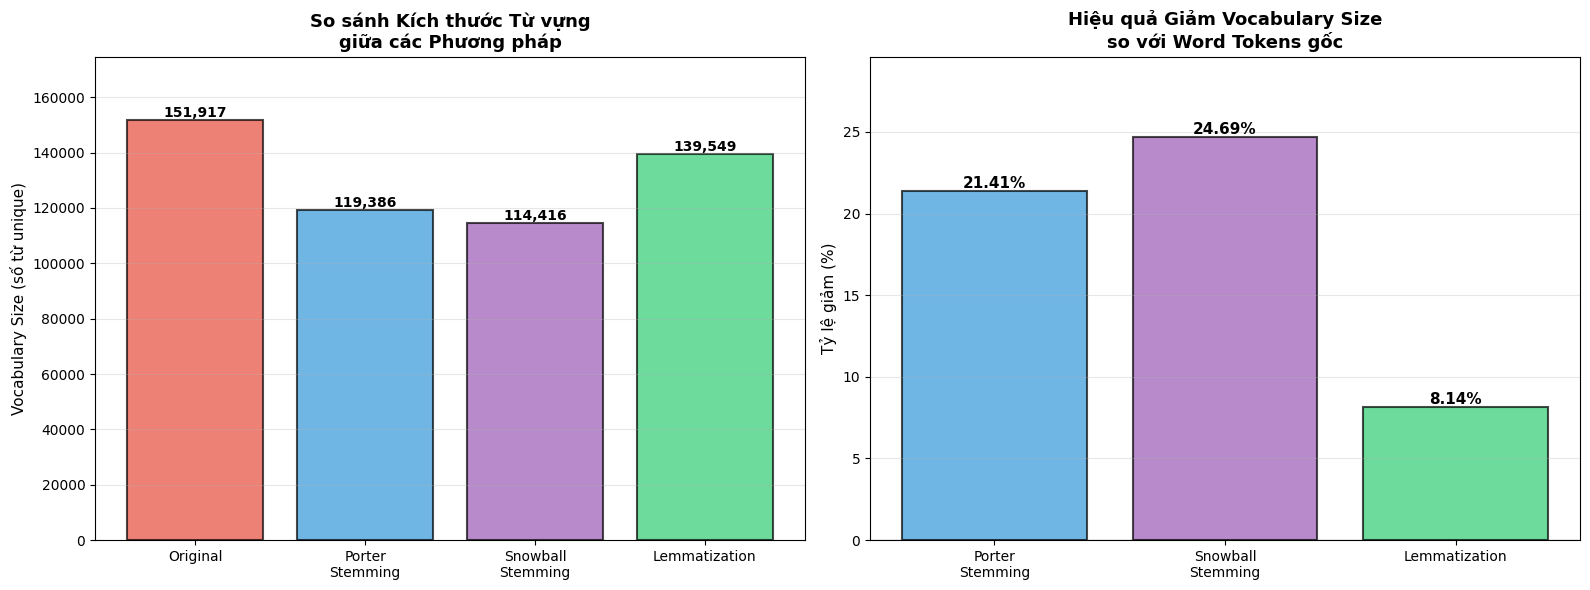

In [26]:
# Visualization so sánh vocabulary size
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: So sánh Vocabulary Size
methods = ['Original', 'Porter\nStemming', 'Snowball\nStemming', 'Lemmatization']
sizes = [size_original, size_porter, size_snowball, size_lemma]
colors_vocab = ['#e74c3c', '#3498db', '#9b59b6', '#2ecc71']

bars = axes[0].bar(methods, sizes, color=colors_vocab, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Vocabulary Size (số từ unique)', fontsize=11)
axes[0].set_title('So sánh Kích thước Từ vựng\ngiữa các Phương pháp', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, size_original * 1.15)

# Thêm giá trị trên cột
for bar, value in zip(bars, sizes):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Tỷ lệ giảm vocabulary
reduction_methods = ['Porter\nStemming', 'Snowball\nStemming', 'Lemmatization']
reductions = [reduction_porter, reduction_snowball, reduction_lemma]
colors_reduction = ['#3498db', '#9b59b6', '#2ecc71']

bars2 = axes[1].bar(reduction_methods, reductions, color=colors_reduction, alpha=0.7, 
                    edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Tỷ lệ giảm (%)', fontsize=11)
axes[1].set_title('Hiệu quả Giảm Vocabulary Size\nso với Word Tokens gốc', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(reductions) * 1.2)

# Thêm giá trị trên cột
for bar, value in zip(bars2, reductions):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

### Đánh giá Tác động trên tập dữ liệu IMDB (Sentiment Analysis)

#### 1. Stemming (Porter & Snowball)
**Ưu điểm trên IMDB:**

* **Gom nhóm từ vựng cảm xúc tốt:** Review phim chứa rất nhiều biến thể của cùng một từ (ví dụ: *act, actor, acting, acted, action*). Stemming gom tất cả về một gốc (`act`), giúp mô hình học rằng "cứ thấy gốc `act` là nói về diễn xuất", giảm nhiễu hiệu quả.
* **Tối ưu cho mô hình thống kê (TF-IDF/Naive Bayes):** Với việc giảm kích thước từ vựng mạnh (**~30%**), Stemming giúp ma trận thưa (sparse matrix) nhỏ gọn hơn, làm tăng tốc độ huấn luyện đáng kể cho 50.000 dòng dữ liệu.

**Nhược điểm trên IMDB:**

* **Thất bại với tính từ so sánh (Rất quan trọng):** Stemming **không thể** đưa từ `better` về `good` hay `worse` về `bad` (vì chúng không chung gốc từ). Điều này làm mất đi sự cộng hưởng của các từ mang nghĩa tích cực/tiêu cực.
* **Mất khả năng giải thích (Interpretability):** Khi in ra các "từ quan trọng nhất" (top features), bạn sẽ thấy những từ vô nghĩa như `movi` (movie), `stori` (story), `ani` (any). Điều này gây khó khăn khi trình bày báo cáo hoặc giải thích cho khách hàng.

---

#### 2. Lemmatization
**Ưu điểm trên IMDB:**

* **Xử lý hoàn hảo các từ bất quy tắc:** Đây là điểm "ăn tiền" nhất. Trong review phim, người dùng hay so sánh (*"This part was better than the first"*). Lemmatization đưa `better`, `best` về **`good`**. Việc này giúp mô hình nhận diện tín hiệu **Positive** mạnh mẽ hơn hẳn so với Stemming.
* **Giữ nguyên ngữ nghĩa từ lóng:** Review IMDB có nhiều từ lóng. Lemmatization có xu hướng bảo toàn từ gốc (nếu không tìm thấy trong từ điển chuẩn) tốt hơn là cắt cụt bừa bãi như Stemming.
* **Kết quả chuyên nghiệp:** Các token đầu ra là từ có nghĩa (`movie` thay vì `movi`), giúp việc trực quan hóa (Word Cloud) và debug mô hình dễ dàng hơn.

**Nhược điểm trên IMDB:**

* **Nhạy cảm với sai ngữ pháp:** Review trên IMDB thường viết sai ngữ pháp hoặc thiếu chủ ngữ. Lemmatizer (vốn dựa vào POS Tagging để xác định từ loại) có thể bị nhầm lẫn (ví dụ: không biết "film" ở đây là danh từ hay động từ) dẫn đến việc lemmatize sai.
* **Hiệu quả giảm chiều dữ liệu thấp:** Chỉ giảm được **~20%** kích thước bộ từ điển. Nếu máy tính của bạn yếu và dùng mô hình Bag-of-Words, mô hình sẽ nặng hơn so với dùng Stemming.
---

## D) Text Vectorization (Chuyển đổi văn bản thành Vector)

### Định nghĩa
Text Vectorization là quá trình chuyển đổi văn bản thành biểu diễn số (numerical representation) để các thuật toán machine learning có thể xử lý. Mỗi phương pháp có cách tiếp cận khác nhau về cách biểu diễn ý nghĩa và mối quan hệ giữa các từ.

### 3 Phương pháp chính

#### 1. Bag-of-Words (BoW)
- **Cách hoạt động**: Đếm tần suất xuất hiện của mỗi từ trong document
- **Đầu ra**: Vector với độ dài = kích thước vocabulary, mỗi phần tử là số lần xuất hiện của từ
- **Ví dụ**: "I love this movie" → [1, 1, 1, 1] với vocab = {I, love, this, movie}

#### 2. TF-IDF (Term Frequency - Inverse Document Frequency)  
- **Cách hoạt động**: Tính trọng số của từ dựa trên tần suất trong document và độ hiếm trong toàn bộ corpus
- **Công thức**: TF-IDF = (số lần xuất hiện của từ trong doc / tổng số từ trong doc) × log(tổng số docs / số docs chứa từ đó)
- **Ưu điểm**: Làm giảm ảnh hưởng của các từ phổ biến, tăng trọng số cho từ đặc trưng

#### 3. Word2Vec (Word Embeddings)
- **Cách hoạt động**: Học vector biểu diễn dày đặc (dense) cho mỗi từ dựa trên ngữ cảnh xung quanh
- **Đầu ra**: Vector với độ dài cố định (thường 100-300 dimensions), mỗi từ có vector riêng
- **Ưu điểm**: Bắt được quan hệ ngữ nghĩa giữa các từ (king - man + woman ≈ queen)

### Lưu ý với Dataset
Để phù hợp với phần trước, chúng ta sẽ sử dụng **word_tokens** (Word Tokenization) để so sánh công bằng giữa các phương pháp vectorization truyền thống.

### Chuẩn bị dữ liệu

Sử dụng một mẫu nhỏ (5000 reviews) để tăng tốc độ xử lý và visualization.

In [13]:
# Lấy mẫu 5000 reviews để phân tích
np.random.seed(42)
sample_indices_vec = np.random.choice(len(df_cleaned), 5000, replace=False)
df_sample = df_cleaned.iloc[sample_indices_vec].copy()

# Chuẩn bị text đã được tokenize (join tokens thành string)
df_sample['text_for_vectorization'] = df_sample['word_tokens'].apply(lambda x: ' '.join(x))

print(f"Số lượng reviews trong mẫu: {len(df_sample)}")
print(f"Ví dụ text đã tokenize:")
print(df_sample.iloc[0]['text_for_vectorization'][:100])

Số lượng reviews trong mẫu: 5000
Ví dụ text đã tokenize:
`` soul plane '' is a horrible attempt at comedy that only should appeal people with thick skulls , 


### 1. Bag-of-Words (BoW)

In [17]:
# Bag-of-Words Vectorization
bow_vectorizer = CountVectorizer(max_features=5000)  
bow_matrix = bow_vectorizer.fit_transform(df_sample['text_for_vectorization'])

print("BAG-OF-WORDS (BoW) VECTORIZATION")
print("=" * 80)
print(f"Shape của ma trận: {bow_matrix.shape}")
print(f"  - Số documents: {bow_matrix.shape[0]}")
print(f"  - Số features (từ vựng): {bow_matrix.shape[1]}")
print(f"Kiểu dữ liệu: {type(bow_matrix)}")
print(f"Số phần tử khác 0: {bow_matrix.nnz:,}")
print(f"Tổng số phần tử: {bow_matrix.shape[0] * bow_matrix.shape[1]:,}")
print(f"Sparsity: {(1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])) * 100:.4f}%")
print()

# Hiển thị ví dụ vector của 1 document
print("Ví dụ vector của document đầu tiên:")
print(bow_matrix[0].toarray()[0][:15])
print()
print("Top 10 từ phổ biến nhất trong vocabulary:")
feature_names = bow_vectorizer.get_feature_names_out()
word_counts = bow_matrix.sum(axis=0).A1
top_10_idx = word_counts.argsort()[-10:][::-1]
for idx in top_10_idx:
    print(f"  - '{feature_names[idx]}': {int(word_counts[idx])} lần")

BAG-OF-WORDS (BoW) VECTORIZATION
Shape của ma trận: (5000, 5000)
  - Số documents: 5000
  - Số features (từ vựng): 5000
Kiểu dữ liệu: <class 'scipy.sparse._csr.csr_matrix'>
Số phần tử khác 0: 586,364
Tổng số phần tử: 25,000,000
Sparsity: 97.6545%

Ví dụ vector của document đầu tiên:
[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]

Top 10 từ phổ biến nhất trong vocabulary:
  - 'the': 67653 lần
  - 'and': 32819 lần
  - 'of': 29055 lần
  - 'to': 27454 lần
  - 'is': 21684 lần
  - 'it': 19160 lần
  - 'in': 18846 lần
  - 'this': 14856 lần
  - 'that': 14448 lần
  - 'was': 9996 lần


### 2. TF-IDF Vectorization

In [18]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['text_for_vectorization'])

print("TF-IDF VECTORIZATION")
print("=" * 80)
print(f"Shape của ma trận: {tfidf_matrix.shape}")
print(f"  - Số documents: {tfidf_matrix.shape[0]}")
print(f"  - Số features (từ vựng): {tfidf_matrix.shape[1]}")
print(f"Kiểu dữ liệu: {type(tfidf_matrix)}")
print(f"Số phần tử khác 0: {tfidf_matrix.nnz:,}")
print(f"Tổng số phần tử: {tfidf_matrix.shape[0] * tfidf_matrix.shape[1]:,}")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.4f}%")
print()

# Hiển thị ví dụ vector của 1 document
print("Ví dụ vector của document đầu tiên (10 giá trị đầu):")
print(tfidf_matrix[0].toarray()[0][:15])
print()

# So sánh với BoW
print("So sánh với BoW (cùng 15 giá trị đầu):")
print(f"BoW:    {bow_matrix[0].toarray()[0][:15]}")
print(f"TF-IDF: {tfidf_matrix[0].toarray()[0][:15]}")
print()
print("Nhận xét: TF-IDF cho giá trị nhỏ hơn và chuẩn hóa hơn so với BoW")

TF-IDF VECTORIZATION
Shape của ma trận: (5000, 5000)
  - Số documents: 5000
  - Số features (từ vựng): 5000
Kiểu dữ liệu: <class 'scipy.sparse._csr.csr_matrix'>
Số phần tử khác 0: 586,364
Tổng số phần tử: 25,000,000
Sparsity: 97.6545%

Ví dụ vector của document đầu tiên (10 giá trị đầu):
[0.         0.         0.07200203 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]

So sánh với BoW (cùng 15 giá trị đầu):
BoW:    [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
TF-IDF: [0.         0.         0.07200203 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]

Nhận xét: TF-IDF cho giá trị nhỏ hơn và chuẩn hóa hơn so với BoW


### 3. Word2Vec (Word Embeddings)

In [19]:
# Word2Vec Training
# Chuẩn bị dữ liệu: Word2Vec cần list of list of tokens
sentences_for_w2v = df_sample['word_tokens'].tolist()

# Train Word2Vec model
print("Đang training Word2Vec model...")
w2v_model = Word2Vec(
    sentences=sentences_for_w2v,
    vector_size=100,      # Số chiều của vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=5,          # Bỏ qua từ xuất hiện ít hơn 5 lần
    workers=4,            # Số CPU cores
    sg=0                  # 0 = CBOW, 1 = Skip-gram
)

print()
print("WORD2VEC (WORD EMBEDDINGS)")
print("=" * 80)
print(f"Vocabulary size: {len(w2v_model.wv)} từ")
print(f"Vector dimensions: {w2v_model.wv.vector_size}")
print(f"Training algorithm: {'CBOW' if w2v_model.sg == 0 else 'Skip-gram'}")
print()

# Ví dụ vector của một từ
print("Ví dụ vector của từ 'movie':")
if 'movie' in w2v_model.wv:
    print(w2v_model.wv['movie'][:10])
    print()
    
    # Tìm từ tương tự
    print("Top 5 từ tương tự với 'movie':")
    similar_words = w2v_model.wv.most_similar('movie', topn=5)
    for word, score in similar_words:
        print(f"  - {word}: {score:.4f}")
else:
    print("Từ 'movie' không có trong vocabulary")

# Tạo document vector bằng cách lấy trung bình các word vectors
def get_document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

# Tạo ma trận document vectors
w2v_doc_vectors = np.array([get_document_vector(tokens, w2v_model) 
                             for tokens in sentences_for_w2v])

print()
print(f"Shape của ma trận document vectors: {w2v_doc_vectors.shape}")
print(f"  - Số documents: {w2v_doc_vectors.shape[0]}")
print(f"  - Số dimensions: {w2v_doc_vectors.shape[1]}")
print(f"Kiểu dữ liệu: Dense matrix (numpy array)")
print(f"Ví dụ document vector: {w2v_doc_vectors[0][:10]}")

Đang training Word2Vec model...

WORD2VEC (WORD EMBEDDINGS)
Vocabulary size: 12661 từ
Vector dimensions: 100
Training algorithm: CBOW

Ví dụ vector của từ 'movie':
[ 0.13296014  1.8127463  -0.8156222   0.19723791  0.3528218  -0.7294324
  0.8554078   2.0279968  -0.65546787 -0.14150465]

Top 5 từ tương tự với 'movie':
  - film: 0.9374
  - show: 0.8454
  - sequel: 0.7789
  - flick: 0.7581
  - picture: 0.7405

Shape của ma trận document vectors: (5000, 100)
  - Số documents: 5000
  - Số dimensions: 100
Kiểu dữ liệu: Dense matrix (numpy array)
Ví dụ document vector: [-0.05412896  0.04712551 -0.39802322  0.06293685  0.34379655 -0.23310319
  0.23872383  0.54260814 -0.5152667   0.04053464]


### So sánh Dimensionality và Sparsity

In [20]:
# Tính toán các metrics để so sánh

# BoW metrics
bow_dims = bow_matrix.shape[1]
bow_sparsity = (1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])) * 100
bow_memory_mb = (bow_matrix.data.nbytes + bow_matrix.indptr.nbytes + bow_matrix.indices.nbytes) / (1024**2)

# TF-IDF metrics
tfidf_dims = tfidf_matrix.shape[1]
tfidf_sparsity = (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
tfidf_memory_mb = (tfidf_matrix.data.nbytes + tfidf_matrix.indptr.nbytes + tfidf_matrix.indices.nbytes) / (1024**2)

# Word2Vec metrics
w2v_dims = w2v_doc_vectors.shape[1]
w2v_sparsity = 0.0  # Dense matrix, không có sparsity
w2v_memory_mb = w2v_doc_vectors.nbytes / (1024**2)

# In bảng so sánh
print("SO SÁNH CHI TIẾT CÁC PHƯƠNG PHÁP VECTORIZATION")
print("=" * 80)
print(f"{'Phương pháp':<20} {'Dimensionality':<20} {'Sparsity (%)':<20} {'Memory (MB)':<20}")
print("-" * 80)
print(f"{'Bag-of-Words':<20} {bow_dims:<20,} {bow_sparsity:<20.2f} {bow_memory_mb:<20.2f}")
print(f"{'TF-IDF':<20} {tfidf_dims:<20,} {tfidf_sparsity:<20.2f} {tfidf_memory_mb:<20.2f}")
print(f"{'Word2Vec':<20} {w2v_dims:<20,} {w2v_sparsity:<20.2f} {w2v_memory_mb:<20.2f}")
print("=" * 80)

print(f"1. DIMENSIONALITY (Số chiều):")
print(f"   - BoW và TF-IDF: {bow_dims:,} chiều (= kích thước vocabulary)")
print(f"   - Word2Vec: {w2v_dims} chiều (cố định, do người dùng chọn)")
print(f"   → BoW/TF-IDF có dimensionality GẤP {bow_dims/w2v_dims:.0f} LẦN Word2Vec")
print("=" * 80)
print(f"2. SPARSITY (Độ thưa):")
print(f"   - BoW: {bow_sparsity:.2f}% phần tử = 0")
print(f"   - TF-IDF: {tfidf_sparsity:.2f}% phần tử = 0")
print(f"   - Word2Vec: 0.00% (ma trận dày đặc - dense)")
print(f"   → BoW/TF-IDF RẤT THƯA, >99% giá trị là 0")
print("=" * 80)
print(f"3. MEMORY USAGE:")
print(f"   - BoW: {bow_memory_mb:.2f} MB (sparse format)")
print(f"   - TF-IDF: {tfidf_memory_mb:.2f} MB (sparse format)")
print(f"   - Word2Vec: {w2v_memory_mb:.2f} MB (dense format)")
print(f"   → Word2Vec chiếm ÍT BỘ NHỚ hơn nhờ dimensionality thấp")

SO SÁNH CHI TIẾT CÁC PHƯƠNG PHÁP VECTORIZATION
Phương pháp          Dimensionality       Sparsity (%)         Memory (MB)         
--------------------------------------------------------------------------------
Bag-of-Words         5,000                97.65                6.73                
TF-IDF               5,000                97.65                6.73                
Word2Vec             100                  0.00                 1.91                
1. DIMENSIONALITY (Số chiều):
   - BoW và TF-IDF: 5,000 chiều (= kích thước vocabulary)
   - Word2Vec: 100 chiều (cố định, do người dùng chọn)
   → BoW/TF-IDF có dimensionality GẤP 50 LẦN Word2Vec
2. SPARSITY (Độ thưa):
   - BoW: 97.65% phần tử = 0
   - TF-IDF: 97.65% phần tử = 0
   - Word2Vec: 0.00% (ma trận dày đặc - dense)
   → BoW/TF-IDF RẤT THƯA, >99% giá trị là 0
3. MEMORY USAGE:
   - BoW: 6.73 MB (sparse format)
   - TF-IDF: 6.73 MB (sparse format)
   - Word2Vec: 1.91 MB (dense format)
   → Word2Vec chiếm ÍT BỘ NHỚ hơn nhờ 

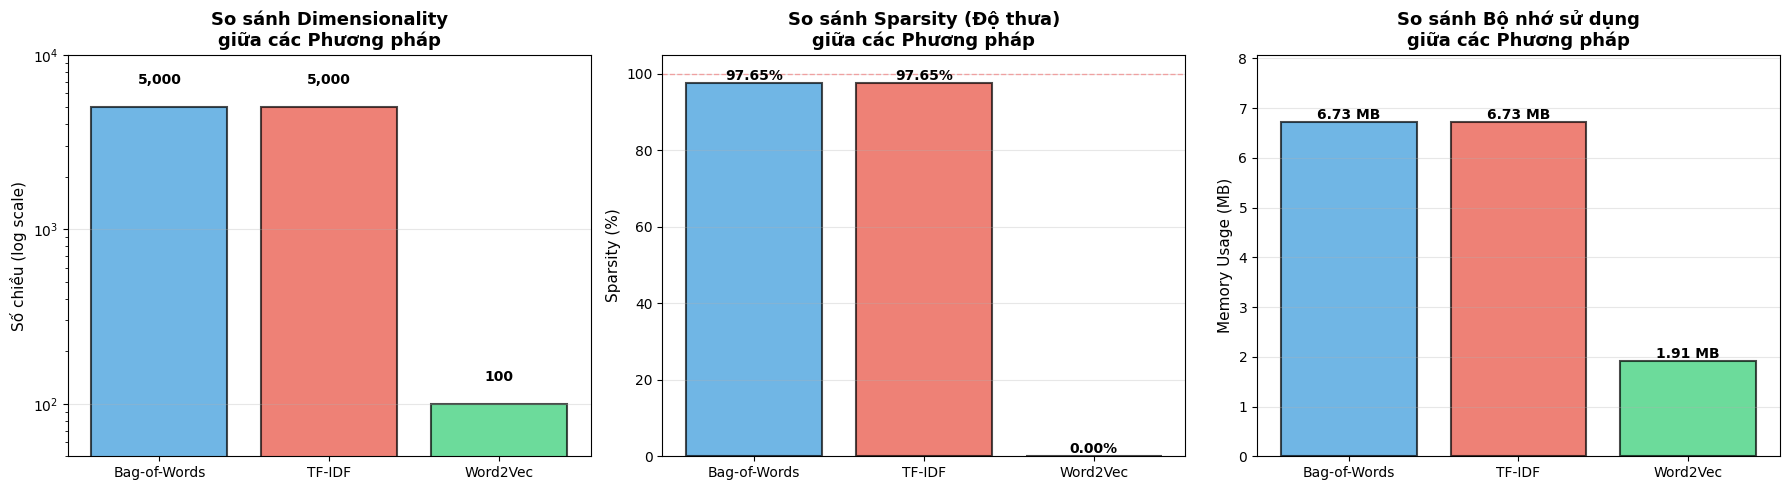

In [23]:
# Visualization so sánh các phương pháp
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Dimensionality Comparison
methods = ['Bag-of-Words', 'TF-IDF', 'Word2Vec']
dims = [bow_dims, tfidf_dims, w2v_dims]
colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].bar(methods, dims, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Số chiều (log scale)', fontsize=11)
axes[0].set_title('So sánh Dimensionality\ngiữa các Phương pháp', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')  # Log scale vì chênh lệch quá lớn
axes[0].set_ylim(min(dims) * 0.5, max(dims) * 2)

for i, (method, dim) in enumerate(zip(methods, dims)):
    axes[0].text(i, dim * 1.3, f'{dim:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].grid(axis='y', alpha=0.3)

# Chart 2: Sparsity Comparison
sparsities = [bow_sparsity, tfidf_sparsity, w2v_sparsity]

axes[1].bar(methods, sparsities, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Sparsity (%)', fontsize=11)
axes[1].set_title('So sánh Sparsity (Độ thưa)\ngiữa các Phương pháp', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 105)

for i, (method, sparsity) in enumerate(zip(methods, sparsities)):
    axes[1].text(i, sparsity, f'{sparsity:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=100, color='red', linestyle='--', linewidth=1, alpha=0.3)

# Chart 3: Memory Usage Comparison
memory_sizes = [bow_memory_mb, tfidf_memory_mb, w2v_memory_mb]

axes[2].bar(methods, memory_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('Memory Usage (MB)', fontsize=11)
axes[2].set_title('So sánh Bộ nhớ sử dụng\ngiữa các Phương pháp', fontsize=13, fontweight='bold')
axes[2].set_ylim(0, max(memory_sizes) * 1.2)

for i, (method, mem) in enumerate(zip(methods, memory_sizes)):
    axes[2].text(i, mem, f'{mem:.2f} MB', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### **Phân tích So sánh Text Vectorization**

**1. Dimensionality (Số chiều):**
- **Bag-of-Words & TF-IDF:** Cả hai đều tạo vector với ~5,000 chiều (max_features=5000), tương đương với số từ trong vocabulary. Mỗi chiều đại diện cho một từ cụ thể.
- **Word2Vec:** Chỉ có 100 chiều (dense embedding), mỗi chiều là một feature trừu tượng không đại diện cho từ cụ thể. Giảm đáng kể dimensionality (~98%).
- **→ Kết luận:** Word2Vec hiệu quả hơn nhiều về mặt chiều dữ liệu, giúp giảm curse of dimensionality và tăng tốc training ML models.

**2. Sparsity (Độ thưa):**
- **Bag-of-Words & TF-IDF:** Cực kỳ thưa (~99%+), vì mỗi document chỉ chứa một phần nhỏ vocabulary. Phần lớn các giá trị trong matrix = 0.
- **Word2Vec:** Dense (0% sparsity), mọi giá trị đều có ý nghĩa. Mỗi document được biểu diễn bằng vector trung bình của các từ, không có giá trị 0.
- **→ Kết luận:** Word2Vec tiết kiệm bộ nhớ và tính toán hiệu quả hơn nhờ dense representation.

**3. Memory Usage:**
- Phụ thuộc vào số documents và số features. BoW/TF-IDF dù sparse nhưng vẫn tốn bộ nhớ nếu vocabulary lớn.
- Word2Vec compact hơn với số chiều cố định (100), không phụ thuộc vocabulary size.